# Experimental Design and Factorial Design Experiment

In [6]:
import pymc3 as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

In [7]:
factor_A = [0, 0, 1, 1]
factor_B = [0, 1, 0, 1]

N = np.array([250, 250, 250, 250])
purchase = np.array([20, 28, 12, 40])

# Frequentist Approach

In [128]:
data = np.vstack([purchase, N - purchase]).T
data

array([[ 20, 230],
       [ 28, 222],
       [ 12, 238],
       [ 40, 210]])

In [129]:
from scipy.stats import chi2_contingency as chisquare

chi2, p, dof, expected = chisquare(data)
print(f"Chi-square value: {chi2:.3f}")
print(f"p-value: {p:.3f}")
print(f"Degrees of freedom: {dof}")

Chi-square value: 19.022
p-value: 0.000
Degrees of freedom: 3


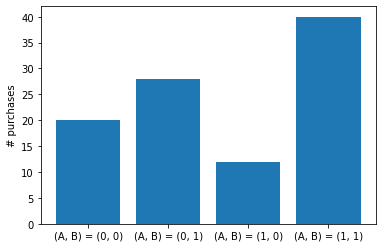

In [130]:
plt.bar(['(A, B) = (0, 0)', '(A, B) = (0, 1)', '(A, B) = (1, 0)', '(A, B) = (1, 1)'], purchase)
plt.ylabel('# purchases')
plt.show()

# Frequentist Approach (Factorial)

https://www.statsmodels.org/dev/examples/notebooks/generated/quasibinomial.html

In [131]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

data = np.vstack([purchase, N - purchase, factor_A, factor_B]).T

df = pd.DataFrame(data)
df.columns = ['purchase', 'no_purchase', 'factor_A', 'factor_B']
df

,purchase,no_purchase,factor_A,factor_B
0,20,230,0,0
1,28,222,0,1
2,12,238,1,0
3,40,210,1,1


In [132]:
mod = smf.glm('purchase + no_purchase ~ C(factor_A) + C(factor_B)', family=sm.families.Binomial(), data=df).fit()
print(mod.summary())

                      Generalized Linear Model Regression Results                      
Dep. Variable:     ['purchase', 'no_purchase']   No. Observations:                    4
Model:                                     GLM   Df Residuals:                        1
Model Family:                         Binomial   Df Model:                            2
Link Function:                           logit   Scale:                          1.0000
Method:                                   IRLS   Log-Likelihood:                -11.950
Date:                         Mon, 07 Feb 2022   Deviance:                       4.4399
Time:                                 13:33:24   Pearson chi2:                     4.41
No. Iterations:                              6                                         
Covariance Type:                     nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

# Frequentist Approach (Factorial, with interaction effect)

In [133]:
# mod = smf.glm('purchase + no_purchase ~ C(factor_A) * C(factor_B)', family=sm.families.Binomial(), data=df).fit()
# print(mod.summary())

In [134]:
df.to_csv('./data.csv')

# Bayesian Approach

In [135]:
with pm.Model() as model:
    theta = pm.Uniform('theta', lower=0, upper=1, shape=len(N))
    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace = pm.sample(5000, chains=2)


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_8485/3675314679.py:4: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [theta]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 5 seconds.


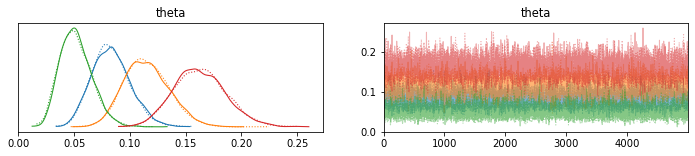

In [136]:
with model:
    az.plot_trace(trace, compact=True)

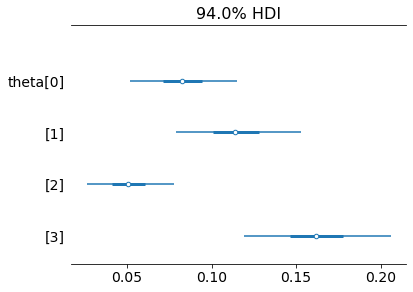

In [137]:
with model:
    az.plot_forest(trace, combined=True)

# Factorial model with a logistic regression

In [138]:
with pm.Model() as model_logistic:
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=2)
    comb = alpha + beta[0] * factor_A + beta[1] * factor_B

    theta = pm.Deterministic('theta', 1 / (1 + pm.math.exp(-comb)))
    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace_logistic = pm.sample(5000, chains=2)


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_8485/2201084098.py:8: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_logistic = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [beta, alpha]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 5 seconds.


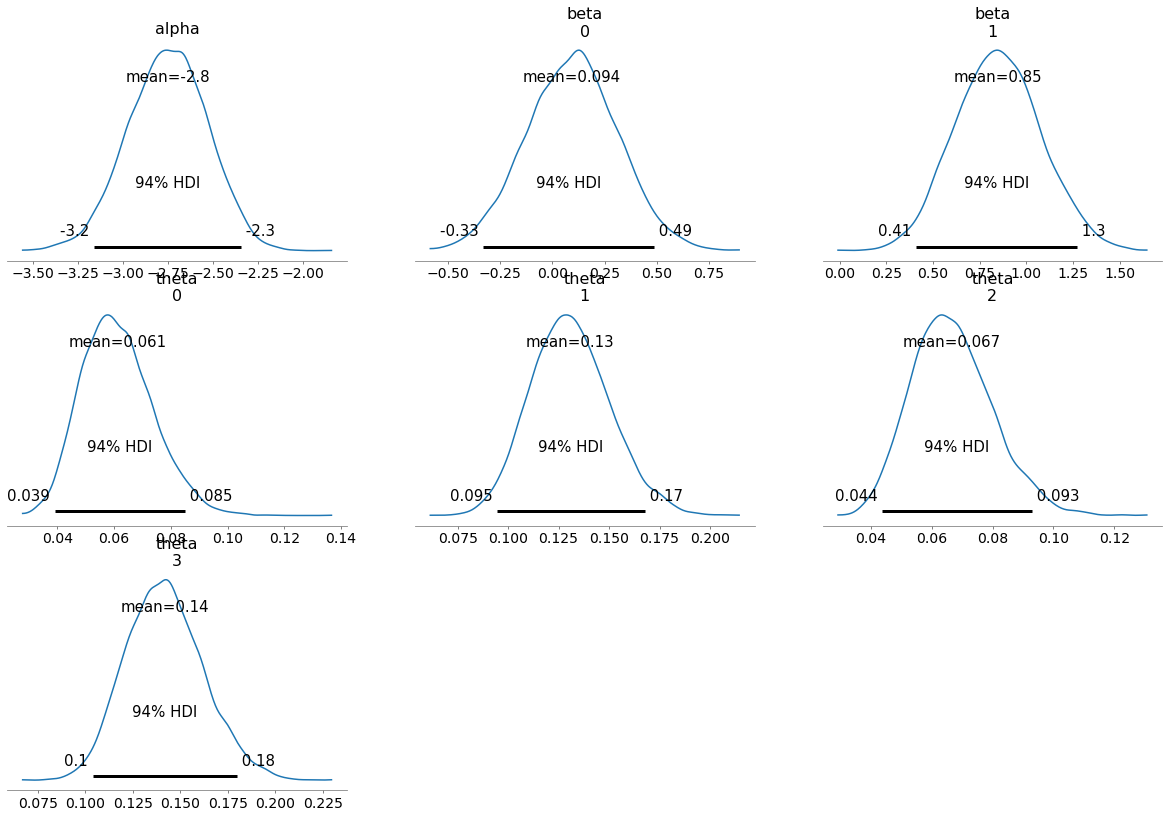

In [152]:
with model_logistic:
    az.plot_posterior(trace_logistic)

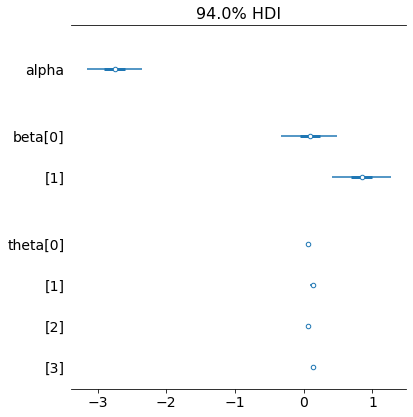

In [140]:
with model_logistic:
    az.plot_forest(trace_logistic, combined=True)

# Factorial model with a logistic regression (with interaction)

In [8]:
with pm.Model() as model_logistic_interaction:
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=2)
    gamma = pm.Normal('gamma', mu=0, sigma=10)
    comb = alpha + beta[0] * factor_A + beta[1] * factor_B + gamma * factor_A * factor_B

    # theta = pm.Deterministic('theta', 1 / (1 + pm.math.exp(-comb)))
    theta = pm.Deterministic('theta', pm.math.invlogit(comb))
    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace_logistic_interaction = pm.sample(5000, chains=2)


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_39138/4125133938.py:10: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_logistic_interaction = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [gamma, beta, alpha]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 10 seconds.


In [12]:
with pm.Model() as model_logistic_interaction:
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=2)
    gamma = pm.Normal('gamma', mu=0, sigma=10)
    #comb = alpha + beta[0] * factor_A + beta[1] * factor_B + gamma * factor_A * factor_B

    fa = pm.Data('fa', factor_A)
    fb = pm.Data('fb', factor_B)
    comb = alpha + beta[0] * fa + beta[1] * fb + gamma * fa * fb

    # theta = pm.Deterministic('theta', 1 / (1 + pm.math.exp(-comb)))
    theta = pm.Deterministic('theta', pm.math.invlogit(comb))
    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace_logistic_interaction = pm.sample(5000, chains=2)


/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_39138/1553887002.py:14: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_logistic_interaction = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [gamma, beta, alpha]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 8 seconds.
The number of effective samples is smaller than 25% for some parameters.


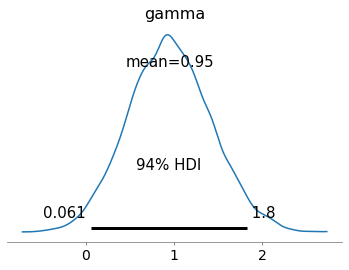

In [13]:
with model_logistic_interaction:
    az.plot_posterior(trace_logistic_interaction, var_names=['gamma'])

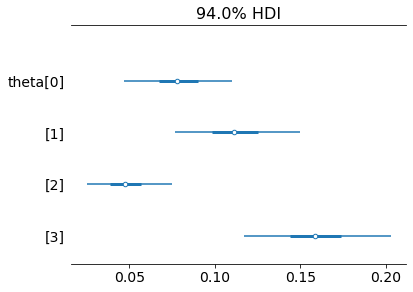

In [14]:
with model_logistic_interaction:
    az.plot_forest(trace_logistic_interaction, var_names=['theta'], combined=True)

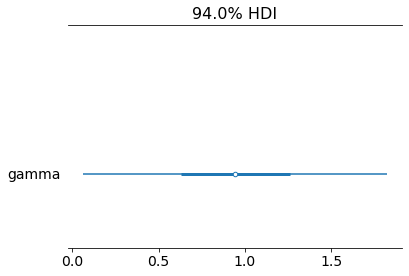

In [15]:
with model_logistic_interaction:
    az.plot_forest(trace_logistic_interaction, var_names=['gamma'], combined=True)

# Model Comparison

In [149]:
cmp_df = az.compare({"without_interaction": trace_logistic, "with_interaction": trace_logistic_interaction}, ic='waic')

Got error No model on context stack. trying to find log_likelihood in translation.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/arviz/stats/stats.py:1458: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning: Using `fro

In [150]:
cmp_df # Smaller the waic, the better the fit.

,rank,waic,p_waic,d_waic,weight,se,dse,warning,waic_scale
with_interaction,0,-13.273879,2.123609,0.000000,1.000000e+00,0.390503,0.000000,True,log
without_interaction,1,-16.653820,4.506798,3.379941,3.108624e-15,0.423178,0.537201,True,log


[]

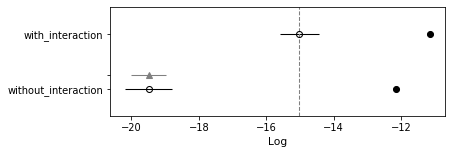

In [148]:
az.plot_compare(cmp_df)
plt.plot()

In [1]:
factor_A

NameError: name 'factor_A' is not defined

In [5]:
factor_A = ['grid', 'list']
factor_B = ['white', 'green']
N = np.array([250, 250, 250, 250])
purchase = np.array([20, 28, 12, 40])

In [ ]:


with pm.Model() as model:
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=2)
    gamma = pm.Normal('gamma', mu=0, sigma=10)

    a0 = pm.Normal('alpha', mu=0, sigma=10)

    a1_tilde = pm.Normal('a1_tilde', mu=0, sigma=10, shape=)
    a1 =

    comb = a0 + a1[factor_A]

    comb = alpha + beta[0] * factor_A + beta[1] * factor_B + gamma * factor_A * factor_B

    theta = pm.Deterministic('theta', 1 / (1 + pm.math.exp(-comb)))
    obs = pm.Binomial('obs', p=theta, n=N, observed=purchase)
    trace = pm.sample(5000, chains=2)